# LendingClub Loan Interest Rate Modelling

Portfolio version prepared for public GitHub presentation. Student IDs, course-submission wording, and private submission details have been removed.


#### **Question 1: Tree Regression** <br>#### This question is designed to provide you with a hands-on guide for running tree-based regressions in Python. 

In [1]:
import numpy as npimport pandas as pdimport matplotlib.pyplot as pltfrom sklearn.tree import DecisionTreeRegressor, plot_tree

This dataset is derived from LendingClub's open dataset (see [here](https://www.openintro.org/data/index.php?data=loans_full_schema)). LendingClub is a fintech company that helps people get loans from investors through its platform. You can retrieve basic information about the company using ```import yfinance as yflendingclub = yf.Ticker('LC')lendingclub.info```

In [16]:
import yfinance as yflendingclub = yf.Ticker('LC')lendingclub.info

{'address1': '595 Market Street', 'address2': 'Suite 200', 'city': 'San Francisco', 'state': 'CA', 'zip': '94105', 'country': 'United States', 'phone': '415 930 7440', 'website': 'https://www.lendingclub.com', 'industry': 'Banks - Regional', 'industryKey': 'banks-regional', 'industryDisp': 'Banks - Regional', 'sector': 'Financial Services', 'sectorKey': 'financial-services', 'sectorDisp': 'Financial Services', 'longBusinessSummary': 'LendingClub Corporation, operates as a bank holding company, that provides range of financial products and services in the United States. It offers deposit products, including savings accounts, checking accounts, and certificates of deposit; patient and education finance loans; and commercial loans, including small business loans. The company also provides consumer loans, such as Unsecured and unsecured, fixed-rate, and fixed-term consumer loans; and secured auto refinance loans. In addition, it operates a lending marketplace platform. The company was inco

## Dataset OverviewThis dataset is derived from LendingClub’s open lending platform data and contains information about loan borrowers and their loan characteristics. The objective of this analysis is to model and predict loan interest rates using borrower attributes such as loan grade and debt-to-income ratio.

In [2]:
# Load datadata = pd.read_csv('loan.csv', index_col=0)data.shape

(14753, 3)

In [3]:
# Check the first few rows of the datasetdata.head()

,interest_rate,grade,debt_to_income
0,7.56,A,17.90
1,12.62,C,10.44
2,5.32,A,13.06
3,23.32,E,0.92
4,7.21,A,28.47


Here `interest_rate` is the target variable, and `grade` and `debt_to_income` are the two features:* `interest_rate`: Interest rate on the loan* `grade`: A letter grade assigned to the loan based on the borrower’s creditworthiness* `debt_to_income`: Debt-to-income ratio, measures the borrower's total monthly debt payments relative to their income

##### **Preprocess the data*** Convert `grade` into numerical values* Drop the rows with missing valuesBefore doing these tasks, please answer the following questions.---

**Question 1.1 <span style='color:lightblue'>[2 points]</span>** Can you show me how many different grades a loan borrower can receive? What is the relative distribution of these grades (hint: show a histogram)?

## Exploration of Loan Grade DistributionBefore building the regression tree model, it is useful to examine the distribution of loan grades in the dataset. Loan grades represent borrower credit risk categories ranging from A (lowest risk) to G (highest risk). Understanding their distribution helps identify how loans are distributed across risk levels.

Unique grades: ['A', 'B', 'C', 'D', 'E', 'F', 'G']Number of different grades: 7Relative distribution of grades:gradeA    0.189995B    0.297973C    0.289704D    0.139904E    0.059920F    0.016675G    0.005829Name: proportion, dtype: float64

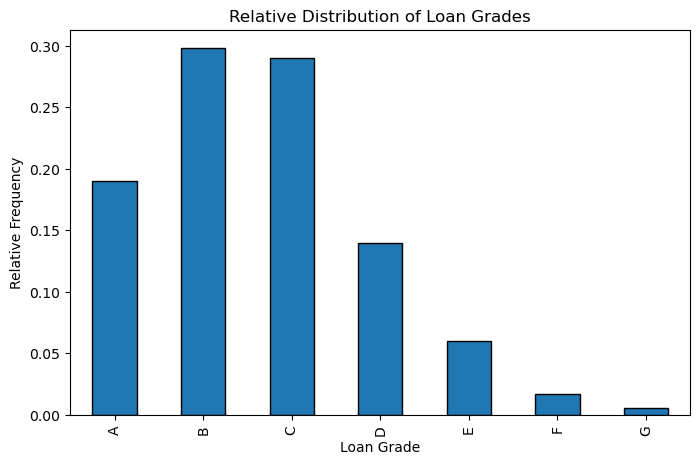

In [4]:
# Show different gradesprint("Unique grades:", sorted(data['grade'].dropna().unique()))print("Number of different grades:", data['grade'].nunique())# Relative distribution of gradesgrade_dist = data['grade'].value_counts(normalize=True).sort_index()print("\nRelative distribution of grades:")print(grade_dist)# Histogram / bar chart of gradesplt.figure(figsize=(8, 5))data['grade'].value_counts(normalize=True).sort_index().plot(kind='bar', edgecolor='black')plt.xlabel("Loan Grade")plt.ylabel("Relative Frequency")plt.title("Relative Distribution of Loan Grades")plt.show()

### Answer to Question 1.1There are **7 different loan grades** in the dataset: **A, B, C, D, E, F, and G**.The relative distribution of grades shows that most loans fall into the middle credit categories. In particular, **grade B (≈29.98%) and grade C (≈28.97%) are the most common**, indicating that a large proportion of borrowers have moderate credit quality.Higher-risk grades appear less frequently in the dataset. For example, **grade F (≈1.67%) and grade G (≈0.58%) are rare**, which suggests that the lending platform issues relatively few loans to borrowers with the lowest credit ratings.The bar chart visually confirms this pattern, showing that the majority of loans are concentrated in grades **A–C**, while grades **E–G** represent a much smaller share of the portfolio.---

**Question 1.2 <span style='color:lightblue'>[1 point]</span>** Why can we drop all the rows that have missing values? <br>Hint: Look at the return value from `print( data.isnull().sum() )`

## Missing Value AnalysisBefore training the regression tree, it is important to examine whether the dataset contains missing values. Missing values can affect model training and prediction accuracy, so identifying and handling them appropriately ensures the reliability of the analysis.

In [5]:
# Check missing values in each columnmissing_counts = data.isnull().sum()missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)print("Columns with missing values:")print(missing_counts)print("\nTotal number of rows with at least one missing value:")print(data.isnull().any(axis=1).sum())print("\nProportion of rows with at least one missing value:")print(data.isnull().any(axis=1).mean())

Columns with missing values:debt_to_income    7dtype: int64Total number of rows with at least one missing value:7Proportion of rows with at least one missing value:0.000474479766827086

### Answer to Question 1.2Only **7 observations contain missing values**, all in the `debt_to_income` variable. This represents approximately **0.047% of the dataset**, which is an extremely small proportion of the total data.Because the number of missing observations is negligible, removing these rows will not materially affect the dataset or the statistical properties of the variables. Dropping them is therefore a simple and reasonable preprocessing step that allows the regression tree model to be trained using complete observations without introducing bias or unnecessary complexity.---

**Question 1.3 <span style='color:lightblue'>[2 points]</span>** Let's now proceed with the previously described feature engineering steps.

## Feature Engineering and Data PreparationThe regression tree model requires numerical inputs. Therefore, the categorical loan grade variable is converted into numerical values. In addition, rows with missing values are removed, and the dataset is reduced to the variables required for modeling: interest rate, loan grade, and debt-to-income ratio.

In [6]:
# This step converts grade into numerical valuesgrade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}data['grade'] = data['grade'].map(grade_map)# This step removes all observations with missing valuesdata = data[['interest_rate', 'grade', 'debt_to_income']].dropna()data.head()

,interest_rate,grade,debt_to_income
0,7.56,1,17.90
1,12.62,3,10.44
2,5.32,1,13.06
3,23.32,5,0.92
4,7.21,1,28.47


### Answer to Question 1.3In this step, feature engineering is performed to prepare the data for the regression tree model.First, the categorical variable **`grade`** is converted into numerical values using a mapping from **A–G to 1–7**. This transformation is necessary because machine learning models in scikit-learn require numerical input rather than categorical text values.Next, the dataset is reduced to the three variables relevant for the regression tree analysis: **`interest_rate`**, **`grade`**, and **`debt_to_income`**. Finally, all rows containing missing values are removed using `dropna()` to ensure that the model is trained only on complete observations.The resulting dataset contains clean numerical variables that are ready to be used for training the regression tree model.---

# **Train the model** <br>We do not consider cross-validation or a train-test split here for simplicity.

**Question 1.4 <span style='color:lightblue'>[2 points]</span>** Define the target variable and the features and make sure they are `numpy arrays`.

## Defining Predictor and Target VariablesTo train the regression tree model, the dataset is separated into predictor variables (features) and the target variable. The predictors used in this analysis are loan grade and debt-to-income ratio, while the target variable is the loan interest rate.

In [7]:
y = data['interest_rate'].to_numpy()X = data[['grade', 'debt_to_income']].to_numpy()print("Shape of y:", y.shape)print("Shape of X:", X.shape)

Shape of y: (14746,)Shape of X: (14746, 2)

### Answer to Question 1.4In this step, the target variable and predictor variables are prepared for the regression tree model.The variable **`interest_rate`** is selected as the target variable `y`, while the features **`grade`** and **`debt_to_income`** are used as the predictor matrix `X`. These two variables represent borrower credit quality and financial risk characteristics that may influence the interest rate assigned to a loan.Both variables are converted into **NumPy arrays** using the `.to_numpy()` method because scikit-learn models require numerical array inputs rather than pandas DataFrame objects.After preprocessing, the dataset contains **14,746 observations** with **two predictor variables**, which are used to train the regression tree model.---

**Question 1.5 <span style='color:lightblue'>[2 points]</span>** Define a function, `train_tree_regression`, that takes four inputs: the target variable, the features, the maximum depth, and a random state, and returns a trained regression tree model. The default values for maximum depth and random state are 3 and 42, respectively.

## Training the Regression Tree ModelA regression tree model is fitted to the dataset to predict interest rates based on borrower characteristics. Regression trees work by recursively partitioning the feature space into regions that minimize prediction error. Each leaf node represents a region where the predicted interest rate is constant.

In [8]:
# Define the function heredef train_tree_regression(y=y, X=X, max_depth=3, random_state=42):    model = DecisionTreeRegressor(max_depth=max_depth, random_state=random_state)    model.fit(X, y)    return model# Fit a regression tree with the default maximum depthreg_tree = train_tree_regression()

##### **Visualize the result**The following function is a recursive tree traversal that visualizes the predicted values in the regions of the feature space of a regression tree. <br>Note: Leaf nodes (or simply leaves) correspond to regions of the feature space.

In [9]:
def plot_leaf_values(tree, X_min, X_max, y_min, y_max, node=0):    """Recursively find leaf nodes and add predicted value annotations"""    # If the node is a leaf, annotate it with the predicted value    if tree.children_left[node] == -1 and tree.children_right[node] == -1:        pred_value = tree.value[node][0][0]  # Extract the prediction        plt.text((X_min + X_max) / 2, (y_min + y_max) / 2, f'{pred_value:.3f}',                  fontsize=10, color='white', ha='center', va='center',                  bbox=dict(facecolor='black', alpha=0.2))                return    # Extract split feature and threshold    feature = tree.feature[node]    threshold = tree.threshold[node]    # Recursively call for left and right children    if feature == 0:    # Splitting on Feature 1 (vertical split)        plot_leaf_values(tree, X_min, threshold, y_min, y_max, tree.children_left[node])        plot_leaf_values(tree, threshold, X_max, y_min, y_max, tree.children_right[node])    elif feature == 1:  # Splitting on Feature 2 (horizontal split)        plot_leaf_values(tree, X_min, X_max, y_min, threshold, tree.children_left[node])        plot_leaf_values(tree, X_min, X_max, threshold, y_max, tree.children_right[node])    return

**Question 1.6 <span style='color:lightblue'>[2 points]</span>** Create a scatter plot of the data points with `grade` on the horizontal axis and `debt_to_income` on the vertical axis. Use the parameters `c=y, edgecolor='k', cmap='coolwarm'`, and `alpha = 0.7`.

## Visualization of Regression Tree Prediction RegionsTo better understand how the regression tree makes predictions, the feature space is visualized. The plot shows how the model partitions the combinations of loan grade and debt-to-income ratio into different regions, with each region corresponding to a predicted interest rate.

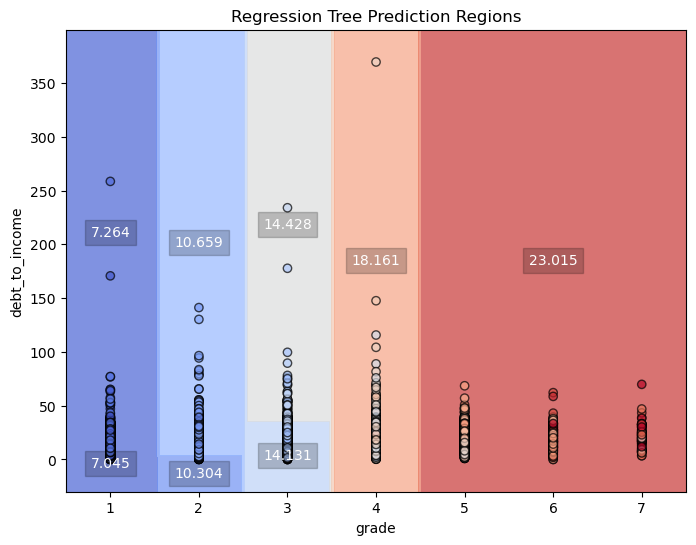

In [10]:
# Create a grid of valuesgrade_min = data['grade'].min() - 0.5grade_max = data['grade'].max() + 0.5dti_min = data['debt_to_income'].min() - 30dti_max = data['debt_to_income'].max() + 30# Create a grid of points within the range of 'grade' and 'debt_to_income' for visualization# h_mesh represents the horizontal axis for 'grade', and v_mesh represents the vertical axis for 'debt_to_income'h_mesh, v_mesh = np.meshgrid(np.linspace(grade_min, grade_max, 100), np.linspace(dti_min, dti_max, 100))grid = np.c_[h_mesh.ravel(), v_mesh.ravel()]# Predict the target for every point in the gridpreds = reg_tree.predict(grid).reshape(h_mesh.shape)# Specify the size of the figureplt.figure(figsize=(8, 6))# Create a filled contour plot to represent the predicted values over the gridlevels = np.linspace(np.min(preds), np.max(preds), 10)plt.contourf(h_mesh, v_mesh, preds, levels=levels, cmap='coolwarm', alpha=0.7)# Scatter plot of the dataplt.scatter(    data['grade'],    data['debt_to_income'],    c=y,    edgecolor='k',    cmap='coolwarm',    alpha=0.7)plt.xlabel("grade")plt.ylabel("debt_to_income")plt.title("Regression Tree Prediction Regions")plot_leaf_values(reg_tree.tree_, grade_min, grade_max, dti_min, dti_max)plt.show()

### Interpretation of the Regression Tree VisualizationThe regression tree partitions the feature space defined by loan grade and debt-to-income ratio into several regions. Each region corresponds to a leaf node where the predicted interest rate is constant.The visualization shows that the model primarily splits on the **grade variable**, creating vertical boundaries across the feature space. This indicates that loan grade is the dominant factor influencing interest rates. Borrowers with higher grades (indicating higher risk) are assigned progressively higher predicted interest rates.The debt-to-income ratio plays a smaller role in the splits, suggesting that interest rates in this dataset are driven mainly by credit grade rather than borrower debt levels.---

**Question 1.7 <span style='color:lightblue'>[2 points]</span>** Can you turn the above code block into a function that takes a model, the features, and maximum depth as inputs and returns a plot showing the splits in the feature space as output? Again, the maximum depth takes a default value of 3; i.e., `max_depth = 3`. The $x$-label and $y$-label can just be "Feature 1" and "Feature 2", respectively.

In [13]:
def plot_tree_splits(model, X, max_depth=3):    grade_vals = X[:, 0]    dti_vals = X[:, 1]    grade_min = grade_vals.min() - 0.5    grade_max = grade_vals.max() + 0.5    dti_min = dti_vals.min() - 30    dti_max = dti_vals.max() + 30    h_mesh, v_mesh = np.meshgrid(        np.linspace(grade_min, grade_max, 100),        np.linspace(dti_min, dti_max, 100)    )    grid = np.c_[h_mesh.ravel(), v_mesh.ravel()]    preds = model.predict(grid).reshape(h_mesh.shape)    plt.figure(figsize=(8, 6))    levels = np.linspace(np.min(preds), np.max(preds), 10)    plt.contourf(h_mesh, v_mesh, preds, levels=levels, cmap='coolwarm', alpha=0.7)    plt.scatter(        X[:, 0], X[:, 1],        c=y,        edgecolor='k',        cmap='coolwarm',        alpha=0.7    )    plt.xlabel("Feature 1 = Grade")    plt.ylabel("Feature 2 = Debt-to-Income")    plt.title(f"Regression Tree Splits (max_depth = {max_depth})")    plot_leaf_values(model.tree_, grade_min, grade_max, dti_min, dti_max)    plt.show()

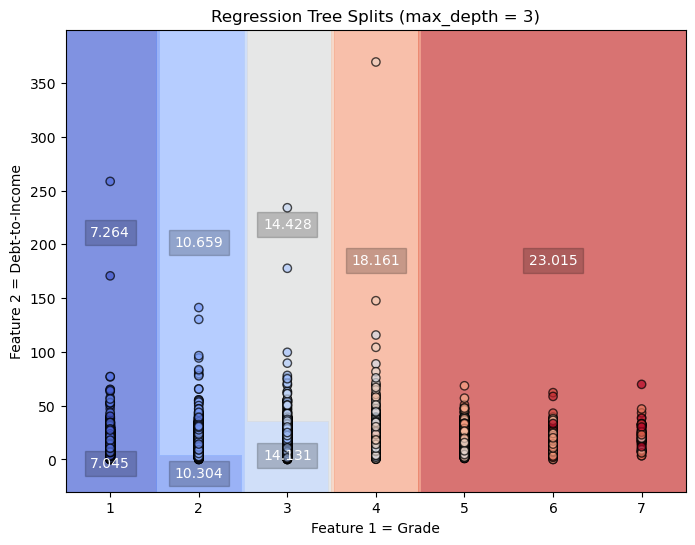

In [14]:
plot_tree_splits(reg_tree, X, max_depth=3)

### InterpretationThe regression tree visualization shows that the model primarily splits on the loan grade variable, producing vertical decision boundaries. This indicates that loan grade is the dominant factor determining the predicted interest rate. Borrowers with higher grades correspond to higher predicted interest rates, while the debt-to-income ratio has a smaller influence on the model’s decision boundaries.---

**Question 1.8 <span style='color:lightblue'>[2 points]</span>** Plot the regression tree <br>Hint: Use `plot_tree`

## Visualization of the Regression Tree StructureThe regression tree structure is visualized to show how the model splits the data based on the predictor variables. Each node in the tree represents a decision rule, and the leaf nodes represent the final predicted interest rate for observations within that region.

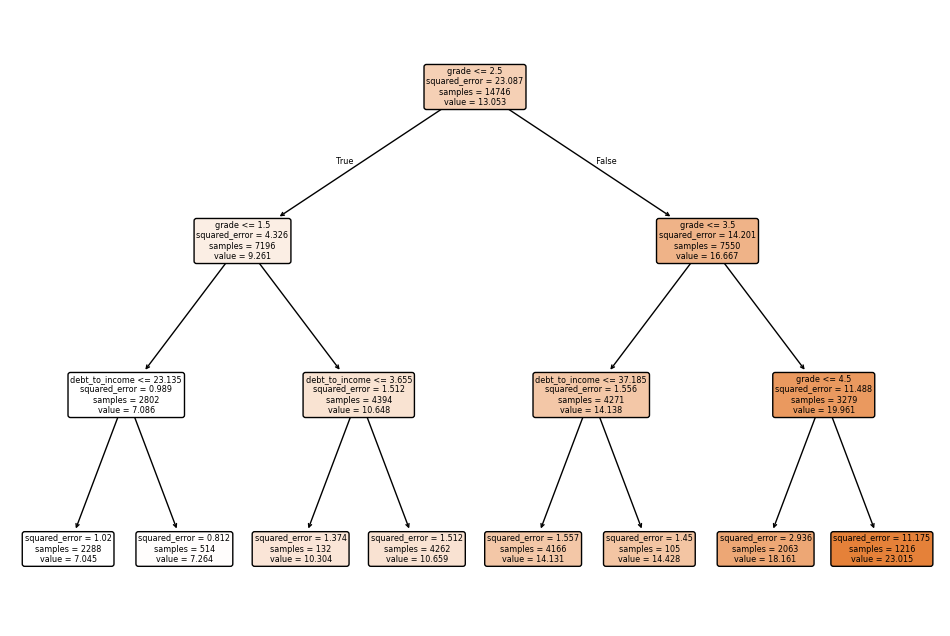

In [15]:
# Plot the tree structureplt.figure(figsize=(12, 8))plot_tree(reg_tree, feature_names=['grade', 'debt_to_income'], filled=True, rounded=True)plt.show()

### Interpretation of the Regression TreeThe regression tree shows how the model predicts interest rates based on loan grade and debt-to-income ratio. The first splits occur on the loan grade variable, indicating that credit grade is the most influential factor in determining interest rates. Borrowers with lower grades (higher risk) are assigned progressively higher predicted interest rates.Further splits occur on the debt-to-income ratio within certain grade categories, suggesting that borrower leverage also contributes to variations in interest rates. The leaf nodes represent the final predicted interest rate for each segment of borrowers.---

# Overall Interpretation of the Regression Tree ModelThis analysis applied a regression tree model to predict loan interest rates using two borrower characteristics: loan grade and debt-to-income ratio. The objective was to understand how these variables influence the pricing of loans on the lending platform.Initial exploration of the dataset showed that loan grades range from A to G, with the majority of loans concentrated in grades B and C. Only a very small number of observations contained missing values (7 out of more than 14,000), representing less than 0.05% of the dataset. As a result, removing these rows did not materially affect the analysis and allowed the model to be trained on complete observations.Since the grade variable is categorical, it was converted into numerical values ranging from 1 (grade A) to 7 (grade G). This transformation enabled the regression tree algorithm to perform numerical splits when partitioning the feature space. The model was then trained using two predictor variables—grade and debt-to-income ratio—to predict the target variable, interest rate.The visualization of prediction regions shows that the regression tree primarily splits along the loan grade axis, producing vertical decision boundaries. This indicates that loan grade is the most influential variable in determining interest rates. As the grade increases (indicating higher credit risk), the predicted interest rate also increases substantially. For example, borrowers in the lowest risk categories have predicted interest rates around 7–10%, while borrowers in the highest risk categories have predicted rates exceeding 20%.The regression tree structure further confirms this relationship. The earliest splits occur on the grade variable, dividing borrowers into broad credit risk groups. Within some of these groups, additional splits based on debt-to-income ratio refine the predictions. This suggests that while borrower leverage contributes to interest rate variation, its influence is secondary compared to credit grade.Overall, the regression tree effectively captures the hierarchical relationship between borrower risk characteristics and loan pricing. The model demonstrates that credit grade serves as the primary driver of interest rate determination, while debt-to-income ratio provides additional segmentation within grade categories. This behavior aligns with real-world lending practices, where credit ratings typically play the dominant role in determining loan interest rates.******